#Sentiment Classification of Product Reviews Using NLP

# 1. Install required libraries

In [20]:
!pip install nltk wordcloud -q


# 2. Import libraries


In [21]:
# ===============================
# BASIC LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# TEXT VISUALIZATION
# ===============================
from wordcloud import WordCloud
from collections import Counter

# ===============================
# NLTK SETUP
# ===============================
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# ===============================
# MACHINE LEARNING
# ===============================
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ===============================
# WARNING CONTROL (OPTIONAL)
# ===============================
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


# 3. Upload dataset


In [22]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully")
print(df.head())

print("\nColumns:")
print(df.columns)

print("\nShape:", df.shape)

Saving Dataset-SA.csv to Dataset-SA (2).csv
Dataset loaded successfully
                                        product_name product_price Rate  \
0  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    5   
1  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    5   
2  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    3   
3  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    1   
4  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    3   

            Review                                            Summary  \
0           super!  great cooler excellent air flow and for this p...   
1          awesome              best budget 2 fit cooler nice cooling   
2             fair  the quality is good but the power of air is de...   
3  useless product                  very bad product its a only a fan   
4             fair                                      ok ok product   

  Sentiment  
0  positive  
1  positiv

# 4. Select needed columns


In [23]:
df = df[['Review', 'Sentiment']].copy()
df.dropna(inplace=True)

df['Sentiment'] = df['Sentiment'].astype(str).str.lower().str.strip()
df['Review'] = df['Review'].astype(str)

print("\nSelected columns preview:")
print(df.head())

print("\nSentiment counts:")
print(df['Sentiment'].value_counts())

# Keep only valid sentiment classes
valid_sentiments = ['positive', 'negative', 'neutral']
df = df[df['Sentiment'].isin(valid_sentiments)].copy()

print("\nFiltered sentiment counts:")
print(df['Sentiment'].value_counts())


Selected columns preview:
            Review Sentiment
0           super!  positive
1          awesome  positive
2             fair  positive
3  useless product  negative
4             fair   neutral

Sentiment counts:
Sentiment
positive    147176
negative     24401
neutral       8811
Name: count, dtype: int64

Filtered sentiment counts:
Sentiment
positive    147176
negative     24401
neutral       8811
Name: count, dtype: int64


# 5. Text preprocessing


In [24]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords


stop_words = set(stopwords.words('english'))

# Important negation words to preserve
negation_words = {
    'not', 'no', 'nor', 'never',
    "don't", "didn't", "won't",
    "isn't", "aren't", "wasn't",
    "weren't", "can't", "couldn't",
    "shouldn't", "wouldn't"
}

stop_words = stop_words - negation_words

def clean_text(text):
    text = str(text).lower()

    # Expand contractions
    text = text.replace("don't", "do not")
    text = text.replace("didn't", "did not")
    text = text.replace("won't", "will not")
    text = text.replace("can't", "can not")
    text = text.replace("isn't", "is not")
    text = text.replace("aren't", "are not")
    text = text.replace("wasn't", "was not")
    text = text.replace("weren't", "were not")
    text = text.replace("couldn't", "could not")
    text = text.replace("shouldn't", "should not")
    text = text.replace("wouldn't", "would not")

    # Convert common chat-style negatives
    text = text.replace("dont", "do not")
    text = text.replace("didnt", "did not")
    text = text.replace("wont", "will not")
    text = text.replace("cant", "can not")
    text = text.replace("isnt", "is not")
    text = text.replace("arent", "are not")
    text = text.replace("wasnt", "was not")
    text = text.replace("werent", "were not")
    text = text.replace("couldnt", "could not")
    text = text.replace("shouldnt", "should not")
    text = text.replace("wouldnt", "would not")

    # Remove links
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    words = text.split()

    # Remove stopwords except negations
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_review'] = df['Review'].apply(clean_text)

print("\nOriginal and cleaned review preview:")
print(df[['Review', 'clean_review']].head())


Original and cleaned review preview:
            Review     clean_review
0           super!            super
1          awesome          awesome
2             fair             fair
3  useless product  useless product
4             fair             fair



# 6. Important words



In [25]:
all_words = " ".join(df['clean_review'])
word_list = all_words.split()
word_freq = Counter(word_list)

print("\nTop 20 important words:")
print(word_freq.most_common(20))


Top 20 important words:
[('product', 29842), ('good', 17445), ('not', 12837), ('awesome', 11294), ('purchase', 11023), ('terrific', 10954), ('nice', 9396), ('worth', 9037), ('wonderful', 9031), ('specified', 8351), ('recommended', 6695), ('money', 5897), ('great', 5704), ('best', 5656), ('brilliant', 5648), ('buy', 5640), ('perfect', 5617), ('every', 5609), ('super', 5608), ('penny', 5608)]


# 7. Input and output


In [26]:
X = df['clean_review']
y = df['Sentiment']

# 8. TF-IDF feature extraction


In [27]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 3))
X_tfidf = tfidf.fit_transform(X)

print("\nTF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (180388, 4955)


# 9. Train-test split


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (144310, 4955)
Test shape: (36078, 4955)


# 10. Train model


In [29]:
model = LogisticRegression(
    max_iter=3000,
    class_weight={
        'positive': 1,
        'negative': 3,
        'neutral': 6
    }
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Model Accuracy: 0.8902101003381562

Classification Report:

              precision    recall  f1-score   support

    negative       0.85      0.78      0.81      4880
     neutral       0.22      0.26      0.24      1762
    positive       0.95      0.95      0.95     29436

    accuracy                           0.89     36078
   macro avg       0.67      0.66      0.66     36078
weighted avg       0.90      0.89      0.89     36078



# 11. Confusion matrix


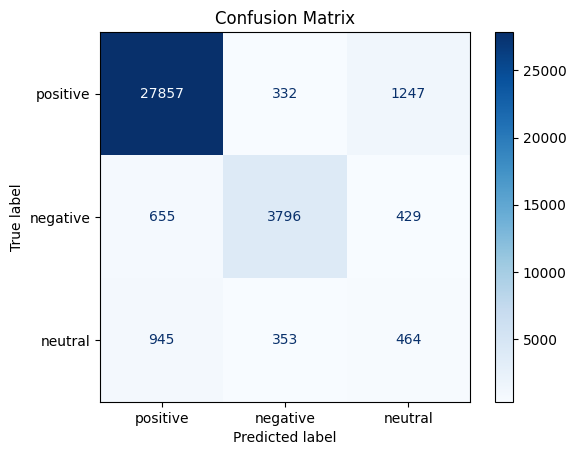

In [30]:
labels_order = ['positive', 'negative', 'neutral']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# 12. Sentiment distribution bar chart


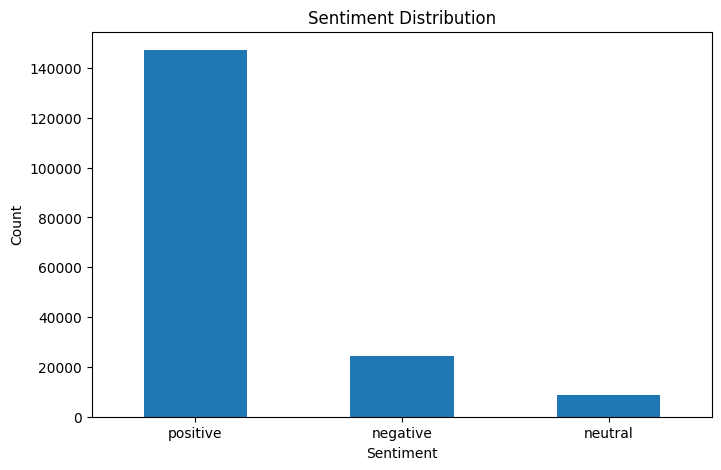

In [31]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# 13. Sentiment distribution pie chart


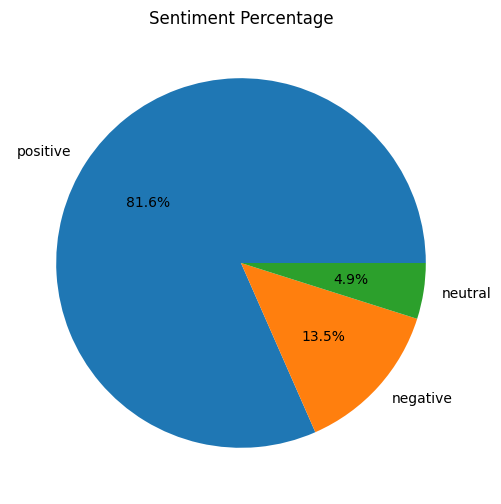

In [32]:
plt.figure(figsize=(6, 6))
sentiment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Percentage")
plt.ylabel("")
plt.show()

# 14. Word cloud


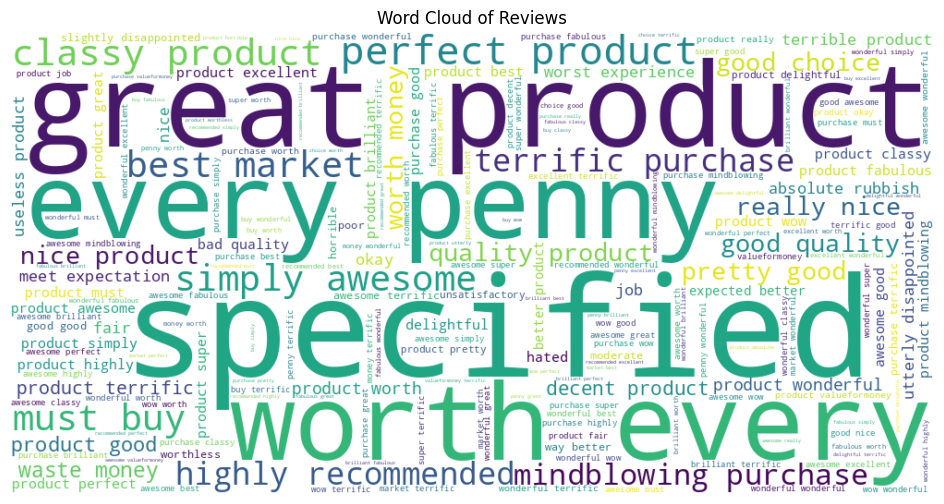

In [33]:
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Reviews")
plt.show()

# 15. Top 10 frequent words graph


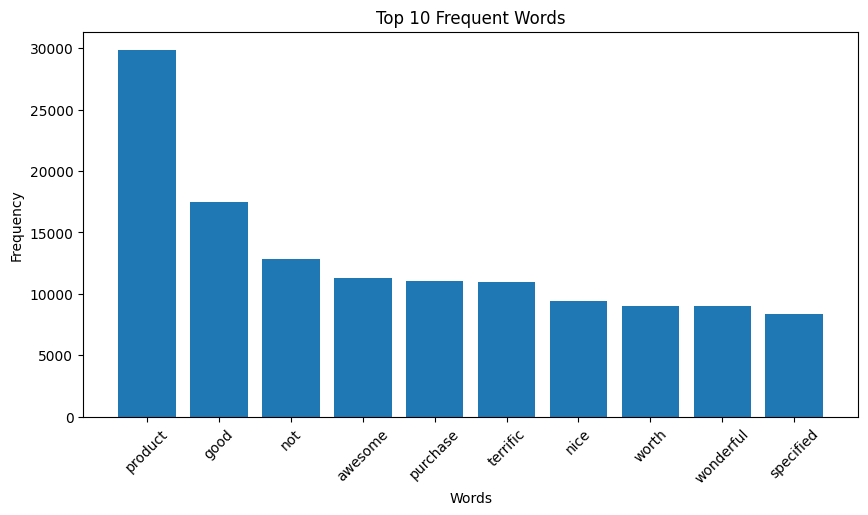

In [34]:
top_words = word_freq.most_common(10)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.title("Top 10 Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()


# 16. Predict custom review


In [35]:
def predict_sentiment_with_graph(review_text):
    cleaned = clean_text(review_text)

    strong_negative_phrases = [
        'not worthy',
        'not working',
        'do not buy',
        'waste money',
        'bad product',
        'poor quality',
        'worst product',
        'not good',
        'very bad',
        'waste product',
        'stopped working',
        'stop working',
        'do not recommend',
        'useless product'
    ]

    neutral_phrases = [
        'average product',
        'okay product',
        'ok product',
        'not bad',
        'fine product',
        'normal quality',
        'decent product',
        'nothing special',
        'acceptable product',
        'works fine',
        'average quality',
        'fine but',
        'just okay',
        'ordinary product'
    ]

    # Rule-based negative detection
    for phrase in strong_negative_phrases:
        if phrase in cleaned:
            classes = ['negative', 'neutral', 'positive']
            probabilities = [90, 5, 5]

            print("\nOriginal Review:", review_text)
            print("Cleaned Review:", cleaned)
            print("Result: This is a BAD review")

            print("\nDetailed Scores:")
            print("negative: 90.00%")
            print("neutral: 5.00%")
            print("positive: 5.00%")

            plt.figure(figsize=(8, 5))
            plt.bar(classes, probabilities)
            plt.title("Review Sentiment Analysis Graph")
            plt.xlabel("Sentiment")
            plt.ylabel("Probability (%)")
            plt.ylim(0, 100)
            plt.show()
            return

    # Rule-based neutral detection
    for phrase in neutral_phrases:
        if phrase in cleaned:
            classes = ['negative', 'neutral', 'positive']
            probabilities = [15, 75, 10]

            print("\nOriginal Review:", review_text)
            print("Cleaned Review:", cleaned)
            print("Result: This is a NEUTRAL review")

            print("\nDetailed Scores:")
            print("negative: 15.00%")
            print("neutral: 75.00%")
            print("positive: 10.00%")

            plt.figure(figsize=(8, 5))
            plt.bar(classes, probabilities)
            plt.title("Review Sentiment Analysis Graph")
            plt.xlabel("Sentiment")
            plt.ylabel("Probability (%)")
            plt.ylim(0, 100)
            plt.show()
            return

    # ML-based prediction
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probabilities = model.predict_proba(vectorized)[0]
    classes = model.classes_

    print("\nOriginal Review:", review_text)
    print("Cleaned Review:", cleaned)

    if prediction == 'positive':
        print("Result: This is a GOOD review")
    elif prediction == 'negative':
        print("Result: This is a BAD review")
    else:
        print("Result: This is a NEUTRAL review")

    print("\nDetailed Scores:")
    for cls, prob in zip(classes, probabilities):
        print(f"{cls}: {prob*100:.2f}%")

    plt.figure(figsize=(8, 5))
    plt.bar(classes, probabilities * 100)
    plt.title("Review Sentiment Analysis Graph")
    plt.xlabel("Sentiment")
    plt.ylabel("Probability (%)")
    plt.ylim(0, 100)
    plt.show()


# 17. Take user input


Enter a product review: average product only 

Original Review: average product only 
Cleaned Review: average product
Result: This is a NEUTRAL review

Detailed Scores:
negative: 15.00%
neutral: 75.00%
positive: 10.00%


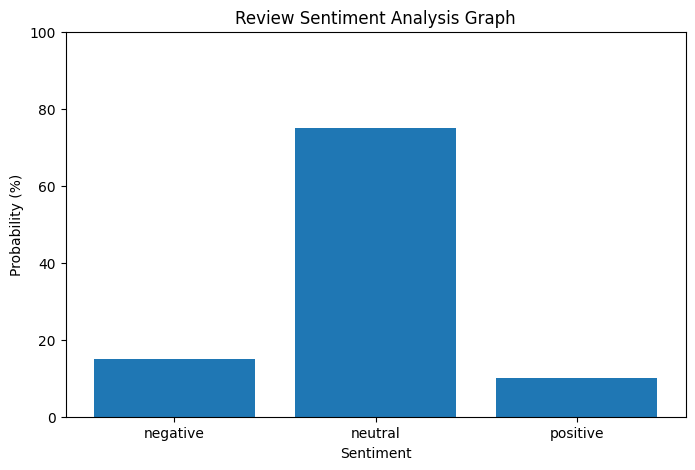

In [42]:
review = input("Enter a product review: ")
predict_sentiment_with_graph(review)